In [54]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
# set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 4)

In [56]:
# load data into pandas dataframes
patients_raw = pd.read_csv('../data/raw/patients.csv', parse_dates=['registration_date'])
vitals_raw = pd.read_csv('../data/raw/vital_signs.csv', parse_dates=['timestamp'])
history_raw = pd.read_csv('../data/raw/clinical_history.csv')
labs_raw = pd.read_csv('../data/raw/laboratory_results.csv', parse_dates=['timestamp'])
outcomes_raw = pd.read_csv('../data/raw/sepsis_outcomes.csv', parse_dates=['diagnosis_time'])

# Create a copy of the raw dataframes to work with
patients = patients_raw.copy()
vitals = vitals_raw.copy()
history = history_raw.copy()
labs = labs_raw.copy()
outcomes = outcomes_raw.copy()

# store all loaded tables in one dictionary for easy access
tables = {
    'patients': patients,
    'vitals': vitals,
    'history': history,
    'labs': labs,
    'outcomes': outcomes
}

# print the shape of each table
for name, table in tables.items():
  print(f"{name} shape: {table.shape}")

patients shape: (600, 5)
vitals shape: (11807, 8)
history shape: (1449, 6)
labs shape: (2430, 8)
outcomes shape: (600, 6)


In [57]:
patients.head()

,patient_id,age,gender,medical_conditions,registration_date
0,1,66,Male,"Diabetes, Cancer (active)",2024-10-19
1,2,42,Female,"Diabetes, Chronic Kidney Disease, Immunosuppre...",2025-06-24
2,3,74,Male,Cancer (active),2024-02-28
3,4,77,Female,"Diabetes, Hypertension",2024-07-31
4,5,25,Female,NaN,2024-07-09


In [58]:
vitals.describe().T

,count,mean,min,25%,50%,75%,max,std
observation_id,11807.0,5904.0,1.0,2952.5,5904.0,8855.5,11807.0,3408.531649
patient_id,11807.0,297.125858,1.0,149.0,294.0,444.0,600.0,172.006979
timestamp,11807,2025-01-05 03:10:59.588379,2024-01-01 04:37:00,2024-07-09 02:07:30,2025-01-15 01:46:00,2025-07-11 20:25:30,2025-12-29 07:13:00,NaN
heart_rate,11490.0,79.892097,43.4,73.2,79.2,85.3,137.4,10.838351
temperature,11514.0,36.84276,34.52,36.55,36.82,37.09,40.25,0.51965
oxygen_saturation,11520.0,97.271389,86.4,96.6,97.4,98.2,100.0,1.555355
respiratory_rate,11519.0,16.543233,8.0,14.6,16.3,18.0,34.6,2.990542
blood_pressure,11545.0,121.214517,55.0,113.8,121.5,129.0,163.9,12.076626


In [59]:
labs.describe().T

,count,mean,min,25%,50%,75%,max,std
lab_id,2430.0,1215.5,1.0,608.25,1215.5,1822.75,2430.0,701.6249
patient_id,2430.0,298.609877,1.0,148.0,300.0,445.0,600.0,172.363294
timestamp,2430,2025-01-01 02:57:24.197530,2024-01-01 12:52:00,2024-07-01 21:03:00,2025-01-10 09:40:00,2025-07-10 09:41:30,2025-12-28 16:48:00,NaN
white_cell_count,2359.0,7.814782,1.0,6.315,7.59,8.97,22.15,2.433649
crp,2370.0,12.306751,0.5,3.325,6.3,9.5,193.1,26.120474
lactate,2356.0,1.141698,0.3,0.8275,1.03,1.23,5.65,0.66575
creatinine,2347.0,0.942833,0.3,0.76,0.91,1.08,2.38,0.286345
platelet_count,2357.0,254.255834,55.0,224.0,255.0,285.0,388.0,46.140953


## Data Quality Checks

In [60]:
# percentage of missing values in each table 
def missing_report(df, name):
  miss = df.isna().mean().mul(100).round(2)
  miss = miss[miss > 0]
  if len(miss):
    print(f"--- {name} ---")
    print(miss.to_string())

for name, df in tables.items():
  missing_report(df, name)

--- patients ---
medical_conditions    25.83
--- vitals ---
heart_rate           2.68
temperature          2.48
oxygen_saturation    2.43
respiratory_rate     2.44
blood_pressure       2.22
--- history ---
diagnosis_history      2.62
medication_history     9.45
treatment_history     14.56
--- labs ---
white_cell_count    2.92
crp                 2.47
lactate             3.05
creatinine          3.42
platelet_count      3.00
--- outcomes ---
diagnosis_time    88.0


In [61]:
# check for duplicate rows in each table  
for name, df in tables.items():
  print(name, 'duplicate rows:', df.duplicated().sum())

patients duplicate rows: 0
vitals duplicate rows: 0
history duplicate rows: 0
labs duplicate rows: 0
outcomes duplicate rows: 0


In [62]:
# check for negative values in numerical columns
for name, df in tables.items():
  num_cols = df.select_dtypes(include=[np.number]).columns
  neg_cols = (df[num_cols] < 0).any()
  neg_cols = neg_cols[neg_cols].index.tolist()
  if neg_cols:
    print(f"--- {name} ---")
    print("Columns with negative values:", neg_cols)
  else:
    print(f"--- {name} ---")
    print("No negative values found.")

--- patients ---
No negative values found.
--- vitals ---
No negative values found.
--- history ---
No negative values found.
--- labs ---
No negative values found.
--- outcomes ---
No negative values found.


In [63]:
# referential integrity
valid_ids = set(patients['patient_id'])
for name, df in [('vitals', vitals), ('history', history), ('labs', labs), ('outcomes', outcomes)]:
  orphans = (~df['patient_id'].isin(valid_ids)).sum()
  print(name, 'orphan patient_ids rows:', orphans)

vitals orphan patient_ids rows: 0
history orphan patient_ids rows: 0
labs orphan patient_ids rows: 0
outcomes orphan patient_ids rows: 0


In [64]:
# Expected ranges for vital signs based on clinical knowledge
ranges = {
  'heart_rate': (30, 220),
  'temperature': (32, 43),
  'oxygen_saturation': (50, 100),
  'respiratory_rate': (5, 60),
  'blood_pressure': (40, 220)
}

for col, (lo, hi) in ranges.items():
  bad = ((vitals[col] < lo) | (vitals[col] > hi)).sum()
  print(f"{col}: {bad} out-of-range values")

heart_rate: 0 out-of-range values
temperature: 0 out-of-range values
oxygen_saturation: 0 out-of-range values
respiratory_rate: 0 out-of-range values
blood_pressure: 0 out-of-range values


## Exploratory Data Analysis

In [65]:
# check proportion of patients with sepsis
print('Sepsis Prevalence:', outcomes['sepsis_event'].mean().round(3))

# check counts of patients with and without sepsis
outcomes['sepsis_event'].value_counts()


Sepsis Prevalence: 0.12


sepsis_event
False    528
True      72
Name: count, dtype: int64

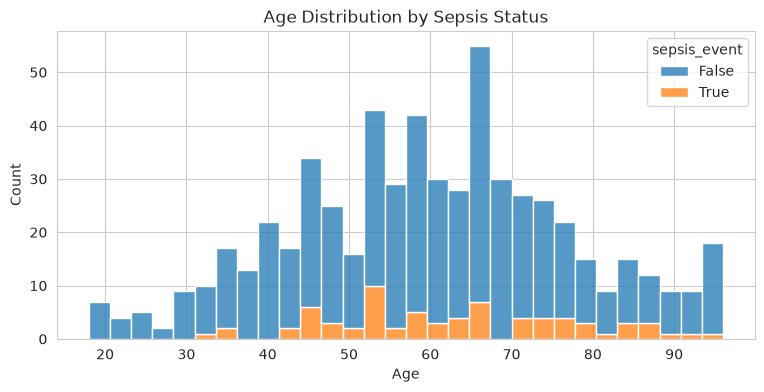

In [66]:
# Age distribution by sepsis status
# merge age with sepsis outcomes
age_df = patients[['patient_id', 'age']].merge(
  outcomes[['patient_id', 'sepsis_event']], 
  on='patient_id', 
  how= 'inner'
)

# plot age distribution by sepsis status
plt.figure()
sns.histplot(data=age_df, x='age', hue='sepsis_event', multiple='stack', bins=30)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Sepsis Status')
plt.show()


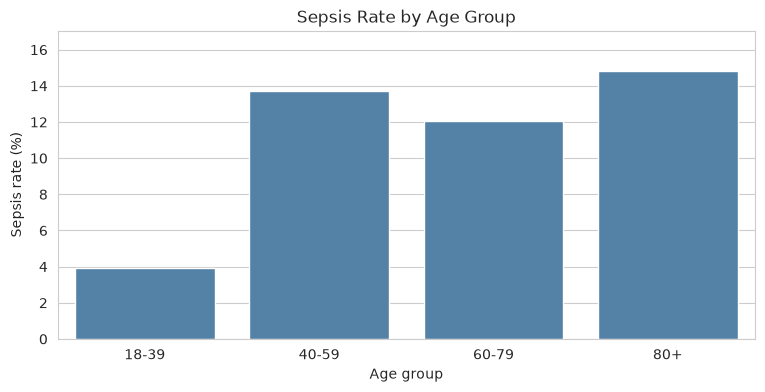

  age_group  sepsis_rate_pct
0     18-39         3.947368
1     40-59        13.698630
2     60-79        12.053571
3       80+        14.814815


In [77]:
# Group patients into clinically interpretable age bands
age_df['age_group'] = pd.cut(
    age_df['age'],
    bins=[0, 39, 59, 79, np.inf],
    labels=['18-39', '40-59', '60-79', '80+'],
    include_lowest=True
)

# Calculate percentage of patients with sepsis in each age band
age_risk = (
    age_df.groupby('age_group', observed=False)['sepsis_event']
    .mean()
    .mul(100)
    .reset_index(name='sepsis_rate_pct')
)

# Plot sepsis prevalence by age band
plt.figure()
sns.barplot(data=age_risk, x='age_group', y='sepsis_rate_pct', color='steelblue')
plt.xlabel('Age group')
plt.ylabel('Sepsis rate (%)')
plt.title('Sepsis Rate by Age Group')
plt.ylim(0, max(age_risk['sepsis_rate_pct']) * 1.15)
plt.show()

print(age_risk)

/tmp/ipykernel_65086/1340751308.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No sepsis', 'Sepsis'])
/tmp/ipykernel_65086/1340751308.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No sepsis', 'Sepsis'])
/tmp/ipykernel_65086/1340751308.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No sepsis', 'Sepsis'])
/tmp/ipykernel_65086/1340751308.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No sepsis', 'Sepsis'])
/tmp

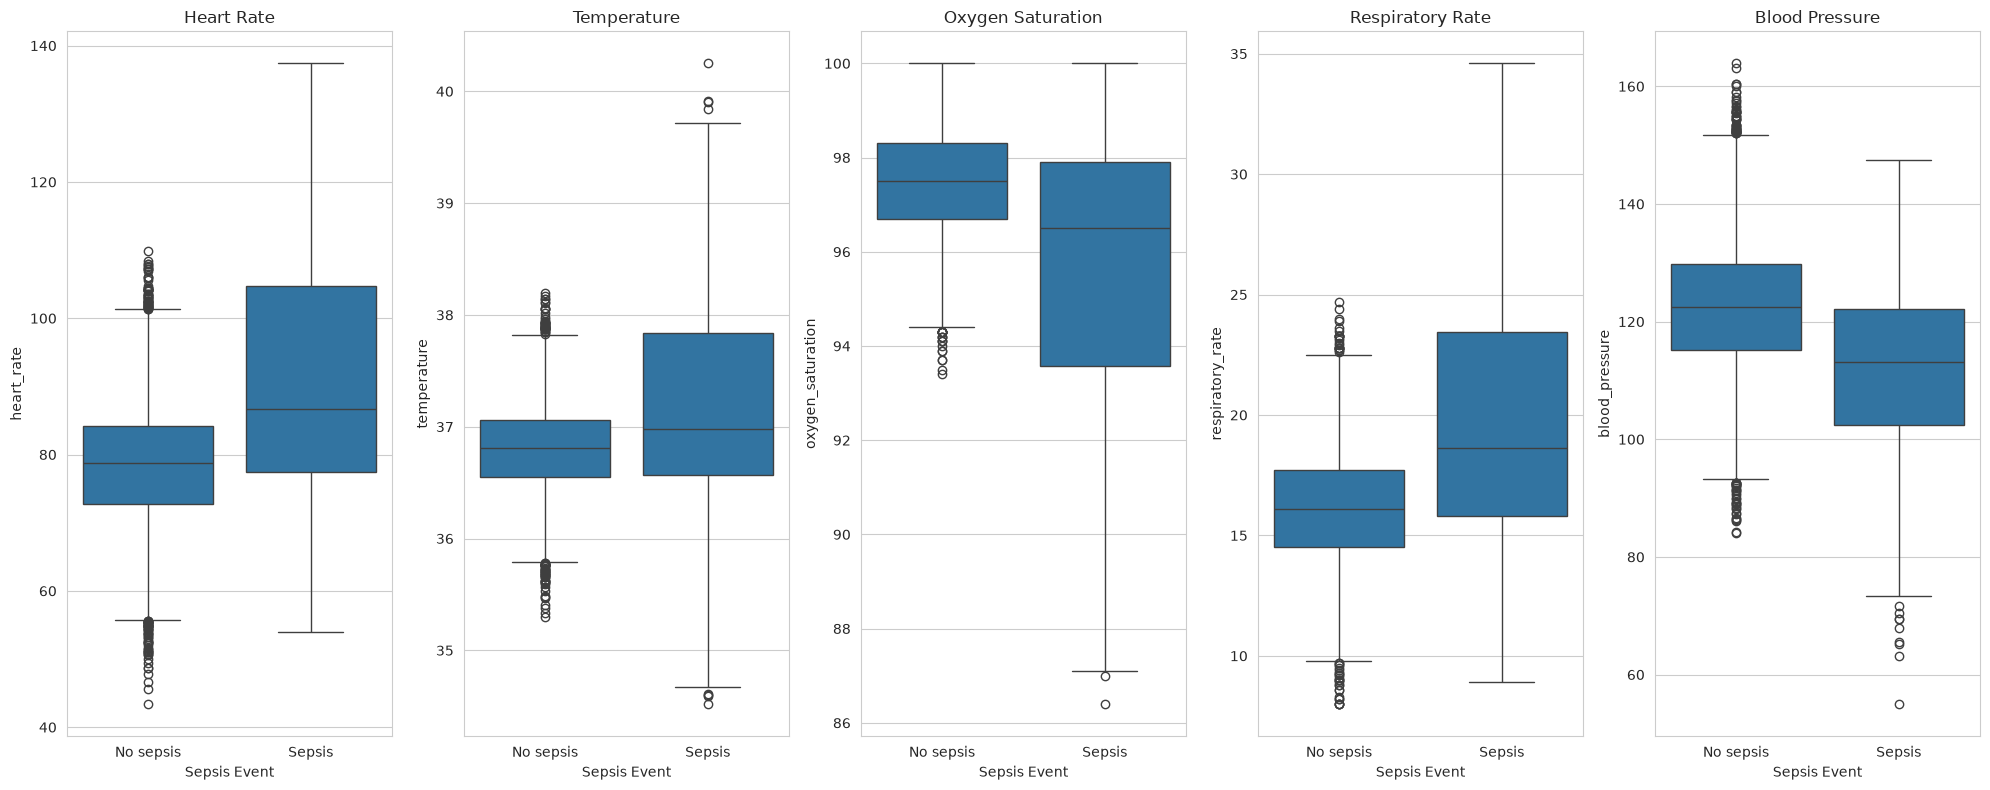

In [67]:
# Vitals: sepsis vs non sepsis readings
vitals_compare = vitals.merge(
  outcomes[['patient_id', 'sepsis_event']],
  on='patient_id',
  how='inner'
)

vitals_cols = [
  'heart_rate',
  'temperature',
  'oxygen_saturation',
  'respiratory_rate',
  'blood_pressure'
]

# Boxplot for each vital sign
fig, axes = plt.subplots(1, len(vitals_cols), figsize=(20, 8), sharey=False)

for ax, col in zip(axes, vitals_cols):
  sns.boxplot(data=vitals_compare, x='sepsis_event', y=col, ax=ax)
  ax.set_title(col.replace('_', ' ').title())
  ax.set_xlabel('Sepsis Event')
  ax.set_xticklabels(['No sepsis', 'Sepsis'])

plt.tight_layout()
plt.show()



/tmp/ipykernel_65086/455192858.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No sepsis', 'Sepsis'])
/tmp/ipykernel_65086/455192858.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No sepsis', 'Sepsis'])
/tmp/ipykernel_65086/455192858.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No sepsis', 'Sepsis'])
/tmp/ipykernel_65086/455192858.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['No sepsis', 'Sepsis'])
/tmp/ipy

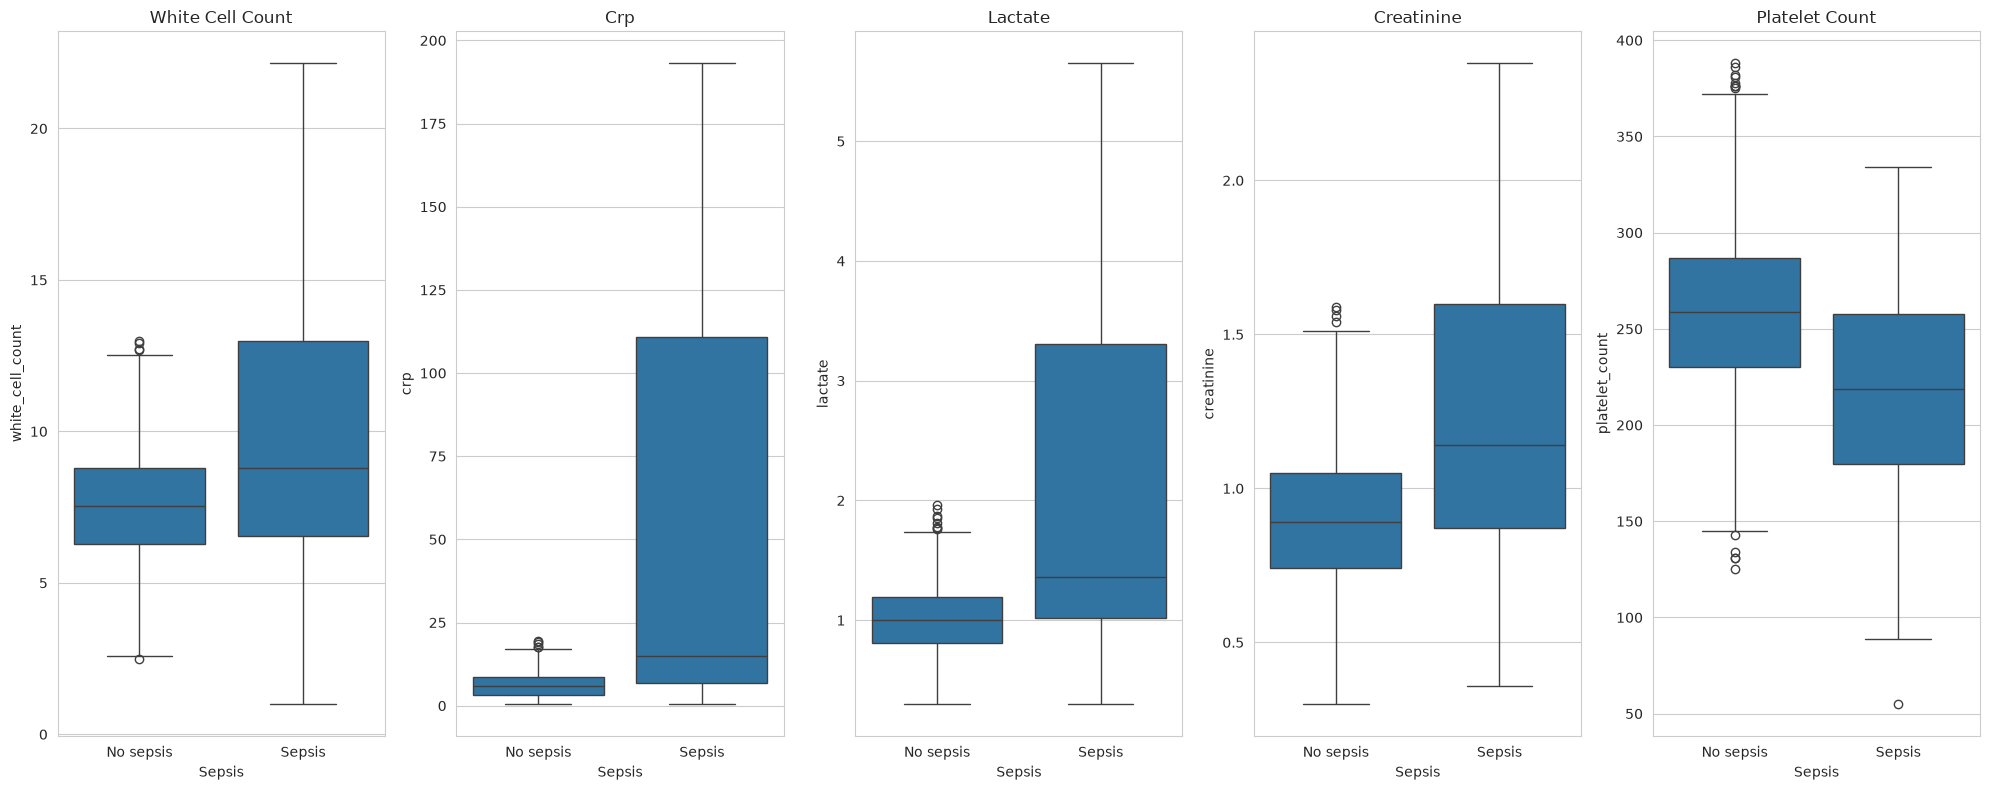

In [68]:
# Labs: sepsis vs non sepsis readings

labs_compare = labs.merge(
  outcomes[['patient_id', 'sepsis_event']],
  on='patient_id',
  how='inner'
)

labs_cols = [
  'white_cell_count',
  'crp',
  'lactate',
  'creatinine',
  'platelet_count'
]

# Boxplot for each lab result
fig, axes = plt.subplots(1, len(labs_cols), figsize=(20, 8), sharey=False)
for ax, col in zip(axes, labs_cols):
    sns.boxplot(
        data=labs_compare,
        x='sepsis_event',
        y=col,
        ax=ax
    )
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Sepsis')
    ax.set_xticklabels(['No sepsis', 'Sepsis'])

plt.tight_layout()
plt.show()

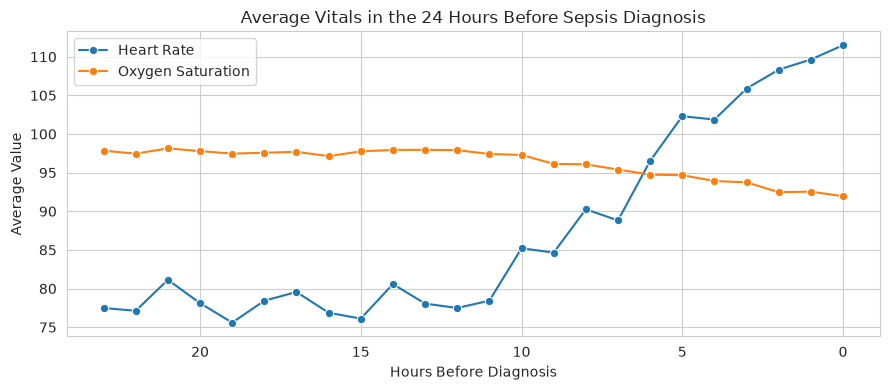

In [69]:
#  Vitals trend before diagnosis
# Work only with sepsis patients who have a diagnosis time
sepsis_patients = outcomes[outcomes['sepsis_event'] == 1][['patient_id', 'diagnosis_time']].copy()

# Merge diagnosis time into vitals
vitals_sepsis = vitals.merge(sepsis_patients, on='patient_id', how='inner')

# Keep only measurements taken before diagnosis and within 24 hours before diagnosis
vitals_sepsis['hours_before_diag'] = (
    (vitals_sepsis['diagnosis_time'] - vitals_sepsis['timestamp']).dt.total_seconds() / 3600
)

vitals_sepsis = vitals_sepsis[
    (vitals_sepsis['hours_before_diag'] >= 0) &
    (vitals_sepsis['hours_before_diag'] <= 24)
].copy()

# Bin time into hourly intervals
vitals_sepsis['hour_bin'] = vitals_sepsis['hours_before_diag'].astype(int)

# Compute average heart rate and oxygen saturation by hour before diagnosis
trend_df = vitals_sepsis.groupby('hour_bin')[['heart_rate', 'oxygen_saturation']].mean().reset_index()
trend_df = trend_df.sort_values('hour_bin', ascending=False)

# Plot the trend

sns.lineplot(data=trend_df, x='hour_bin', y='heart_rate', marker='o', label='Heart Rate')
sns.lineplot(data=trend_df, x='hour_bin', y='oxygen_saturation', marker='o', label='Oxygen Saturation')

plt.gca().invert_xaxis()
plt.title('Average Vitals in the 24 Hours Before Sepsis Diagnosis')
plt.xlabel('Hours Before Diagnosis')
plt.ylabel('Average Value')
plt.legend()
plt.tight_layout()
plt.show()

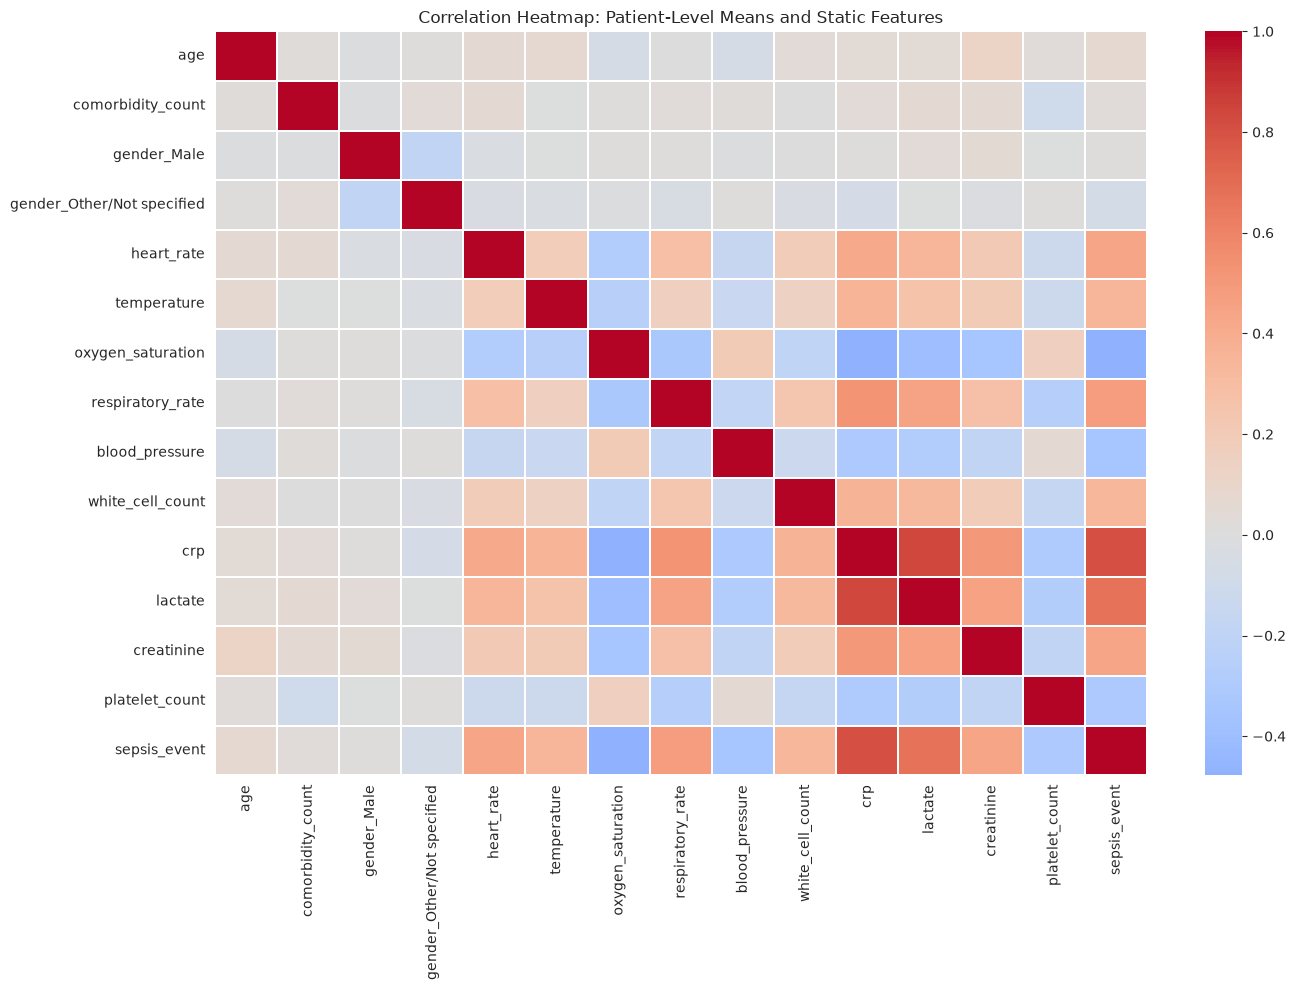

In [70]:
# F. Correlation heatmap using patient-level means

# Patient-level mean vitals
vitals_means = vitals.groupby('patient_id')[[
    'heart_rate',
    'temperature',
    'oxygen_saturation',
    'respiratory_rate',
    'blood_pressure'
]].mean().reset_index()

# Patient-level mean labs
labs_means = labs.groupby('patient_id')[[
    'white_cell_count',
    'crp',
    'lactate',
    'creatinine',
    'platelet_count'
]].mean().reset_index()

# Static patient features
static = patients[['patient_id', 'age', 'gender', 'medical_conditions']].copy()
static['comorbidity_count'] = static['medical_conditions'].fillna('').apply(
    lambda x: 0 if x == '' or x == 'None reported' else len(x.split(','))
)
static = pd.get_dummies(static[['patient_id', 'age', 'comorbidity_count', 'gender']], columns=['gender'], drop_first=True)

# Merge everything
corr_df = static.merge(vitals_means, on='patient_id', how='inner').merge(labs_means, on='patient_id', how='inner')
corr_df = corr_df.merge(outcomes[['patient_id', 'sepsis_event']], on='patient_id', how='inner')

# Correlation matrix
corr_matrix = corr_df.drop(columns=['patient_id']).corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.3)
plt.title('Correlation Heatmap: Patient-Level Means and Static Features')
plt.tight_layout()
plt.show()

In [71]:
# missingness by outcome
missing_by_outcome = outcomes.merge(vitals, on='patient_id', how='left').groupby('sepsis_event').apply(lambda x: x.isna().mean())
print(missing_by_outcome)

              outcome_id  patient_id  diagnosis_time  \
sepsis_event                                           
False                0.0         0.0             1.0   
True                 0.0         0.0             0.0   

              hospitalisation_required  outcome_status  observation_id  \
sepsis_event                                                             
False                              0.0             0.0             0.0   
True                               0.0             0.0             0.0   

              timestamp  heart_rate  temperature  oxygen_saturation  \
sepsis_event                                                          
False               0.0    0.026555     0.025106           0.024334   
True                0.0    0.028946     0.022743           0.024121   

              respiratory_rate  blood_pressure  
sepsis_event                                    
False                 0.024237        0.022402  
True                  0.025500        0.020675

In [72]:
# number of measurements per patient for vitals and labs
vitals_counts = vitals.groupby('patient_id').size().reset_index(name='vitals_count')
labs_counts = labs.groupby('patient_id').size().reset_index(name='labs_count')

print(vitals_counts.describe())
print(labs_counts.describe())

       patient_id  vitals_count
count  600.000000    600.000000
mean   300.500000     19.678333
std    173.349358      6.040890
min      1.000000     10.000000
25%    150.750000     15.000000
50%    300.500000     19.000000
75%    450.250000     25.000000
max    600.000000     30.000000
       patient_id  labs_count
count  600.000000  600.000000
mean   300.500000    4.050000
std    173.349358    1.415688
min      1.000000    2.000000
25%    150.750000    3.000000
50%    300.500000    4.000000
75%    450.250000    5.000000
max    600.000000    6.000000


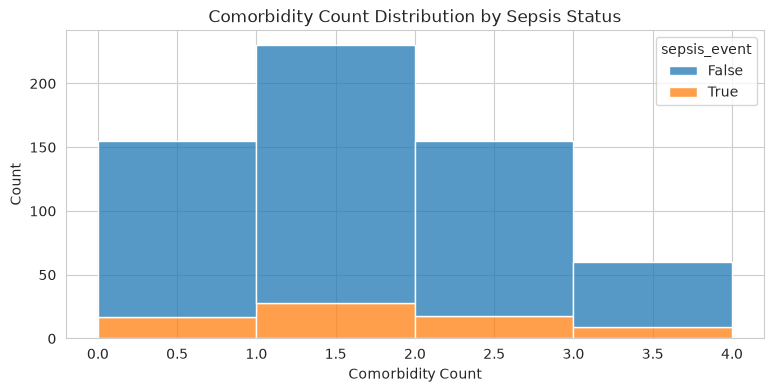

In [73]:
# comorbidity count distribution by sepsis status
comorbidity_df = static.merge(outcomes[['patient_id', 'sepsis_event']], on='patient_id', how='inner')

sns.histplot(data=comorbidity_df, x='comorbidity_count', hue='sepsis_event', multiple='stack', bins=range(0, comorbidity_df['comorbidity_count'].max() + 2))
plt.xlabel('Comorbidity Count')
plt.ylabel('Count')
plt.title('Comorbidity Count Distribution by Sepsis Status')
plt.show()

In [74]:
vitals.columns

Index(['observation_id', 'patient_id', 'timestamp', 'heart_rate',
       'temperature', 'oxygen_saturation', 'respiratory_rate',
       'blood_pressure'],
      dtype='str')

In [75]:

vitals_cols = [
  'heart_rate',
  'temperature',
  'oxygen_saturation',
  'respiratory_rate',
  'blood_pressure'
]

labs_cols = [
  'white_cell_count',
  'crp',
  'lactate',
  'creatinine',
  'platelet_count'
]


vitals = vitals.sort_values(['patient_id', 'timestamp'])
labs = labs.sort_values(['patient_id', 'timestamp'])

vitals[vitals_cols] = vitals.groupby('patient_id')[vitals_cols].transform(lambda s: s.ffill())
vitals[vitals_cols] = vitals[vitals_cols].fillna(vitals[vitals_cols].median())

labs[labs_cols] = labs.groupby('patient_id')[labs_cols].transform(lambda s: s.ffill())
labs[labs_cols] = labs[labs_cols].fillna(labs[labs_cols].median())

print('Remaining missing values -> vitals', vitals[vitals_cols].isna().sum().sum(), '& labs', labs[labs_cols].isna().sum().sum())  
                                                                          


Remaining missing values -> vitals 0 & labs 0


In [76]:
# save cleaned data to processed folder
patients.to_csv('../data/processed/patients_cleaned.csv', index=False)
vitals.to_csv('../data/processed/vital_signs_cleaned.csv', index=False)
history.to_csv('../data/processed/clinical_history_cleaned.csv', index=False)
labs.to_csv('../data/processed/laboratory_results_cleaned.csv', index=False)
outcomes.to_csv('../data/processed/sepsis_outcomes_cleaned.csv', index=False)